In [189]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [190]:
import json

# includes historical rutin data as last record
with open("spectra_data.json", "r") as file:
    spectra_json = json.load(file)

In [191]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
from scipy.interpolate import interp1d
from sklearn.preprocessing import minmax_scale
from minisom import MiniSom

np.random.seed(42)
lengths = list(set([len(spec['absorbance']) for spec in spectra_json]))
spectra_data = []
min_wn = 663 # Historical rutin minimum wavenumber
max_wn = 400

for spec in spectra_json:
    wavenumbers = spec['wn']
    max_wn = max([max_wn, max(wavenumbers)])
    absorbance = spec['absorbance'] 
    spectra_data.append((wavenumbers, absorbance))

# 2. Interpolate to a Common Axis
# Define the target wavenumber range (e.g., matching the highest resolution)
common_wavenumbers = np.linspace(min_wn, max_wn, max(lengths))
interpolated_absorbances = []

for w, a in spectra_data:
    # Linear interpolation for missing values
    f_interp = interp1d(w, a, kind='linear', bounds_error=False, fill_value=0)
    a_interp = f_interp(common_wavenumbers)
    interpolated_absorbances.append(a_interp)

interpolated_absorbances = np.array(interpolated_absorbances)

# 3. Normalize Absorbance
# Min-Max scaling per spectrum (row-wise) to map values between 0 and 1
normalized_data = minmax_scale(interpolated_absorbances, axis=1)


In [192]:
import pickle

# Import the trained som:
with open('trained_som.pkl', 'wb') as f:
    pickle.dump(som, f)

<IPython.core.display.Javascript object>


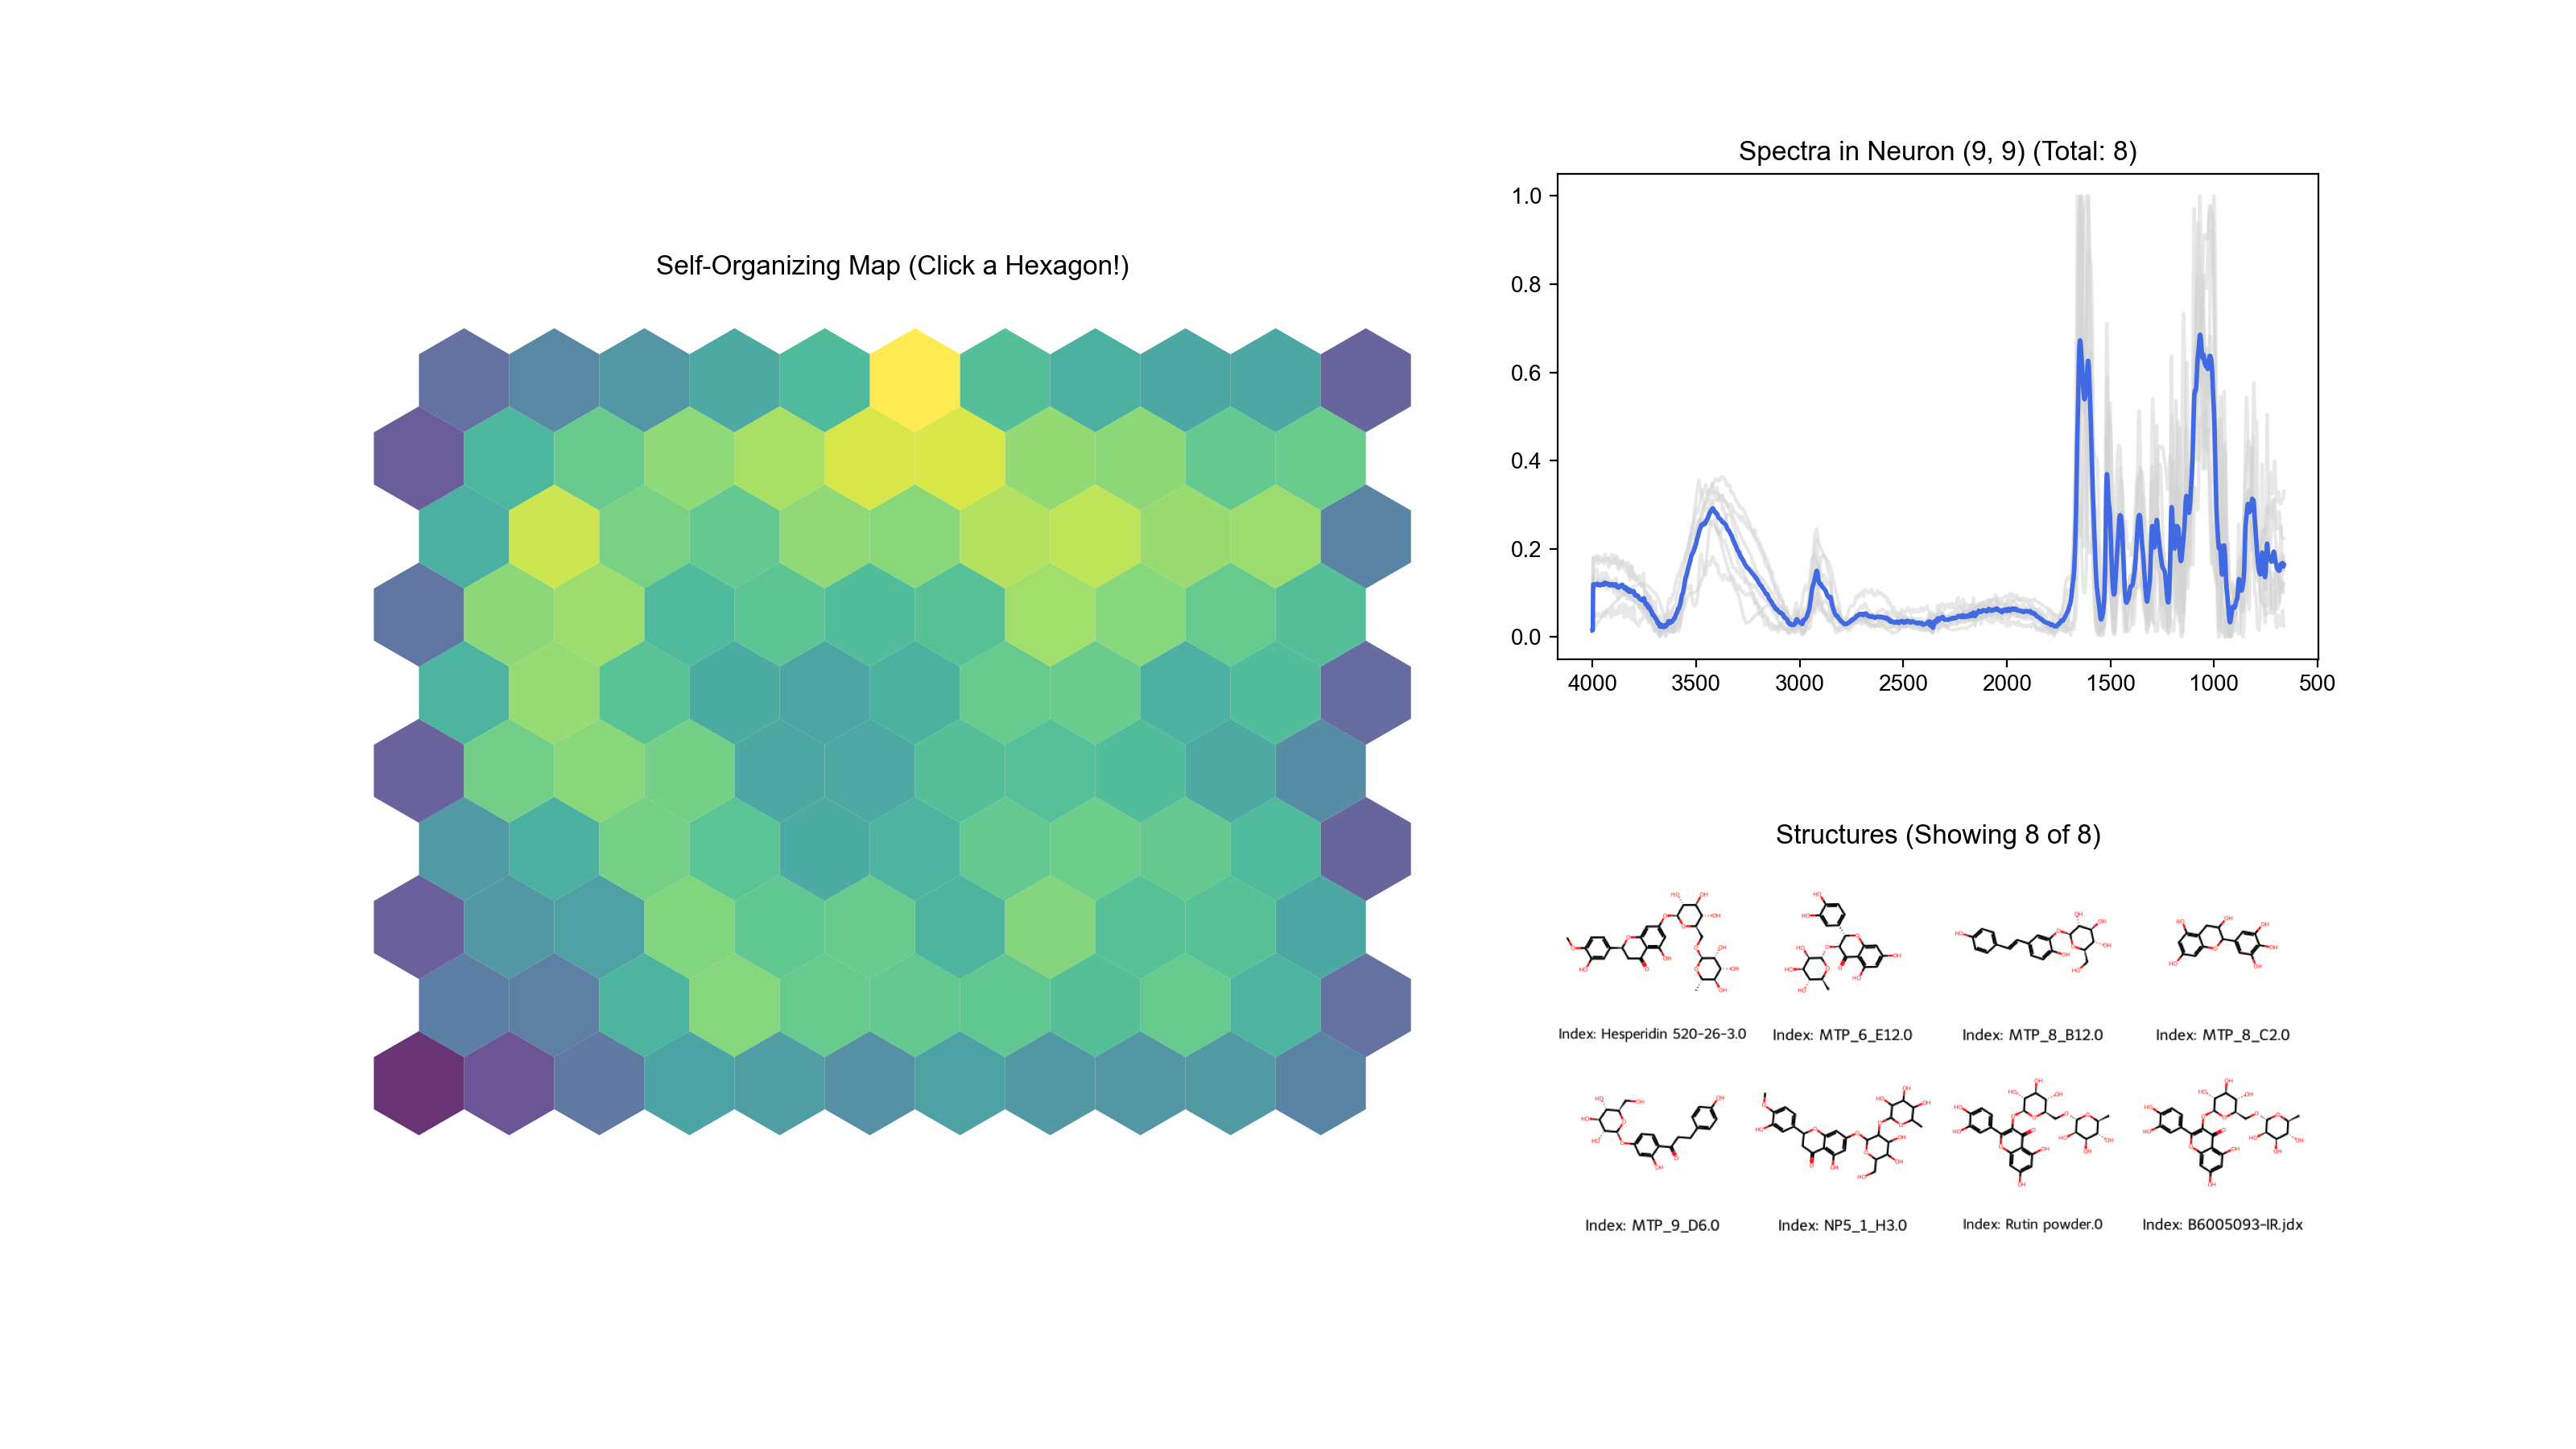

In [194]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import matplotlib.gridspec as gridspec
from rdkit import Chem
from rdkit.Chem import Draw
import tkinter as tk
from tkinter import messagebox


# 1. Map each spectrum index to its Best Matching Unit (BMU)
bmus = np.array([som.winner(x) for x in normalized_data])
neuron_to_spectra = {}

for idx, (bmu_i, bmu_j) in enumerate(bmus):
    neuron_coord = (bmu_i, bmu_j)
    if neuron_coord not in neuron_to_spectra:
        neuron_to_spectra[neuron_coord] = []
    neuron_to_spectra[neuron_coord].append(idx)

# 2. Setup the Multi-Panel Figure using GridSpec
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.5, 1])

# ax_som spans both rows on the left
ax_som = fig.add_subplot(gs[:, 0]) 
# ax_spec is top right, ax_struct is bottom right
ax_spec = fig.add_subplot(gs[0, 1])
ax_struct = fig.add_subplot(gs[1, 1])

fig.subplots_adjust(wspace=0.1, hspace=0.3)

# 3. Draw the static U-Matrix on the left panel (ax_som)
u_matrix = som.distance_map()
patches = []
colors = []
hex_radius = 1 / np.sqrt(3)
hex_centers = {}

for i in range(grid_x):
    for j in range(grid_y):
        x = i + 0.5 * (j % 2)
        y = j * np.sqrt(3) / 2
        hex_centers[(i, j)] = (x, y)
        
        hex_patch = RegularPolygon((x, y), numVertices=6, radius=hex_radius, 
                                   orientation=np.radians(60), edgecolor='black')
        patches.append(hex_patch)
        colors.append(u_matrix[i, j])

p = PatchCollection(patches, cmap='viridis', alpha=0.8)
p.set_array(np.array(colors))
ax_som.add_collection(p)

# Overlay data points
for idx, (bmu_i, bmu_j) in enumerate(bmus):
    x, y = hex_centers[(bmu_i, bmu_j)]
    ax_som.plot(x + np.random.uniform(-0.2, 0.2), 
                y + np.random.uniform(-0.2, 0.2), 
                marker='', color='red', markersize=2, alpha=0.5)

ax_som.set_aspect('equal')
ax_som.axis('off')
ax_som.set_title("Self-Organizing Map (Click a Hexagon!)")

# Initialize right panels
ax_spec.set_title("Spectra Viewer")
ax_struct.set_title("Chemical Structures Viewer")
ax_struct.axis('off')

# 4. Define the Interactive Click Event Handler
def on_click(event):
    table  = []
    if event.inaxes != ax_som:
        return
    
    click_x, click_y = event.xdata, event.ydata
    if click_x is None or click_y is None:
        return

    # Find closest hexagon
    min_dist = float('inf')
    closest_neuron = None
    for neuron_coord, (hx, hy) in hex_centers.items():
        dist = np.hypot(click_x - hx, click_y - hy)
        if dist < min_dist:
            min_dist = dist
            closest_neuron = neuron_coord

    # Update Spectra Panel
    ax_spec.clear()
    ax_struct.clear()
    ax_struct.axis('off')
    ax_spec.invert_xaxis()
    
    spectra_indices = neuron_to_spectra.get(closest_neuron, [])
    
    if spectra_indices:
        ax_spec.set_title(f"Spectra in Neuron {closest_neuron} (Total: {len(spectra_indices)})")
        for idx in spectra_indices:
            ax_spec.plot(common_wavenumbers, normalized_data[idx], color='lightgray', alpha=0.5)
        mean_spectrum = np.mean(normalized_data[spectra_indices], axis=0)
        ax_spec.plot(common_wavenumbers, mean_spectrum, color='royalblue', linewidth=2)
        
        # --- NEW: Process and Display SMILES ---
        # Cap at 12 structures so the grid doesn't become unreadable for dense clusters
        display_indices = spectra_indices[:12] 
        mols   = []
        labels = []
        recs   = []
        
        for idx in display_indices:
            smiles = spectra_json[idx]["smiles"]
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                mols.append(mol)
                labels.append(f'Index: {spectra_json[idx]["sample_id"]}')
                recs.append([spectra_json[idx]["sample_id"], spectra_json[idx]["smiles"]])
        if mols:
            # Generate a composite image of the structures
            img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=labels, returnPNG=False)
            ax_struct.imshow(np.asarray(img))
            ax_struct.set_title(f"Structures (Showing {len(mols)} of {len(spectra_indices)})")
            
        else:
            ax_struct.text(0.5, 0.5, "Invalid SMILES in this neuron.", ha='center', va='center')
            
    else:
        ax_spec.set_title(f"Neuron {closest_neuron} (Empty)")
        ax_struct.set_title("No Structures")
        
    fig.canvas.draw_idle()

# Connect the event
fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

